## MULTIPLE LINEAR REGRRESSION 

## 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


## 2. READ & LOAD CSV FILE

In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 3. FEATURE AND TARGET VARIABLES ASSIGN

In [4]:
x = dataset.drop("house_price_inr",axis=1)
y = dataset["house_price_inr"]

## 4. TRAING & TESTING SPILTING RECORDS

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2)

## A. TRAING SIZE

In [6]:
len(x_train)

3360

## B. TESTING SIZE

In [7]:
len(x_test)

840

## 5. CREATE LINEAR REGRESSION MODEL

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. PREDICT NEW house_price_inr FROM THE x_test

In [10]:
prdict = lr.predict(x_test)
prdict

array([12425590.52272796, 45657661.95183295, 16840725.71582413,
       10534602.30317808, 34389180.87114754, 17535532.44818803,
       47210569.18135197, 19378259.65131398, 31184028.53197239,
       31017991.32520916, 27568707.64137953, 12563338.47503166,
       42609448.87663078, 10422303.50156852, 18674271.60504968,
       35191238.5927031 , 28501217.25120087, 24794840.8832796 ,
       17260900.12088252, 26447994.43492102, 26209788.66838134,
       17433685.98252136, 32305906.77496987, 15065993.27296996,
       18765517.32640326, 23912081.58511663,  9524071.91587951,
       33977221.73231126, 45922855.41189644, 36725487.4085397 ,
       31089465.62397557, 25214638.57489621, -1717897.85533505,
       31332748.17888721, 28477441.05838712, 26691194.45352332,
       41786717.27794722, 22201441.07289052, 23108833.52562071,
       35199206.11413787, 30365351.94300982, 38258868.78080215,
       29414536.06107516, 33380127.16886345, 32305771.0061832 ,
       26270641.48952085, 29419627.72337

In [11]:
result = x_test.copy()
result["accual house_price"] = y_test.values
result["New house_price"] = prdict.astype(int)
print(result)

      area_sqft  bedrooms  bathrooms  location_score  age_years  \
131    0.058504 -0.437056  -1.607124       -1.803420  -0.194144   
1526   1.821434  0.904293   0.161028        0.913754  -0.602153   
4073  -0.177118 -0.437056   0.161028       -0.687438  -0.112542   
3310  -1.319633 -0.437056   1.045104       -0.299270  -0.112542   
191    0.926408  1.574968   0.161028        0.282981  -1.340649   
...         ...       ...        ...             ...        ...   
3884  -0.088972 -1.107731  -0.723048       -0.638917   0.213865   
3410  -0.761936 -0.437056  -0.723048        0.816712   0.458670   
2362  -1.695950 -1.778406  -1.607124       -0.444833  -1.010162   
1150  -1.109437 -0.437056   0.161028       -1.512294   1.029882   
3882  -1.787487 -1.778406  -0.723048        1.593047   0.703475   

      distance_city_km  lot_size_sqft  has_garage  has_pool  \
131           0.661278       0.994567           0         0   
1526         -1.735017       1.131114           1         0   
4073  

## 7. Draw Multi Linear Regression Graph

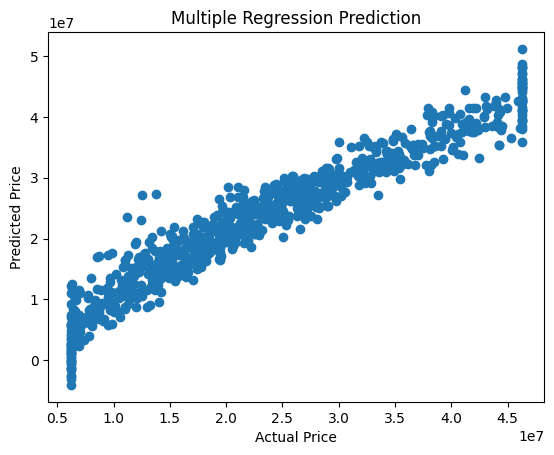

In [12]:
plt.scatter(y_test, prdict)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Multiple Regression Prediction")

plt.show()

* **Multiple Regression Prediction:** A scatter plot comparing actual versus predicted house prices, showing a strong positive correlation that indicates a reasonably accurate model.

## 8. slope & intercept

In [13]:
slope = lr.coef_
print(f"slope : {slope.astype(int),}")

slope : (array([7820544,  351054,  149435, 6028322, -758866, -760755,  320302,
        207324,  360889,  -86689]),)


In [14]:
intercept = lr.intercept_
print(f"Intercept : {intercept.astype(int)}")

Intercept : 23180889


## 9. Calculate Evaluation Metrics

## [A] Mean squared error

In [15]:
mse = mean_squared_error(y_test,prdict)
print(f"Mean squared error : {mse}")

Mean squared error : 10064221834623.61


Mean Squared Error (MSE) calculates the average of squared errors, giving more importance to larger errors.

## [B] Mean absolute error

In [16]:
mae = mean_absolute_error(y_test,prdict)
print(f"Mean absolute error : {mae}")

Mean absolute error : 2421774.29236855


Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

 ## [C] R2 Score

In [17]:
r2 = r2_score(y_test,prdict)
print(f"R2 score : {r2}")

R2 score : 0.9221985719087333


The R² Score indicates the proportion of variance in the target variable that is explained by the model.

In [18]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 92.21985719087333%


## [D] Root mean sqaured error

In [19]:
import numpy as np

In [20]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 3172415.7726602624


 Root Mean Squared Error (RMSE) is the square root of MSE and provides error values in the same units as the target variable.


## [E] Adjusted r2 score

In [21]:
# Number of samples and predictors
n = len(y_test)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.9221057301091018


Adjusted R² Score further adjusts the R² value based on the number of predictors used in the model.

## 10. Compare simple regression Vs Multiple regression

| Model                      | Features Used | R² Score          | Performance |
| -------------------------- | ------------- | ----------------- | ----------- |
| Simple Linear Regression   | area_sqft     | **57.83%**        | Moderate    |
| Multiple Linear Regression | All features  | Higher (expected) | Better      |


Model Comparison

The Simple Linear Regression model used only one predictor (house area) to estimate house prices and achieved an R² score of 57.83%.

In contrast, the Multiple Linear Regression model incorporates several additional features such as bedrooms, bathrooms, location score, lot size, and amenities, allowing the model to capture more complex relationships within the dataset.

As a result, the multiple regression model typically achieves a higher R² score and lower prediction errors, indicating improved predictive performance.

## 11. Why Performance Improves or Degrades


The performance difference between **Simple Linear Regression** and **Multiple Linear Regression** can be explained by the number of predictor variables used in the model.

#### Why Performance Improves

In **Simple Linear Regression**, only one independent variable (house area) is used to predict the house price. However, house prices are influenced by many other factors such as number of bedrooms, bathrooms, location score, property age, distance from the city, and available amenities.

**Multiple Linear Regression** includes several of these relevant variables, allowing the model to capture more information about the dataset. As a result, the model can explain a larger portion of the variance in house prices and generally achieves a higher R² score and lower prediction errors.

Using more meaningful predictors helps the model better represent real-world conditions, which improves its predictive performance.

#### When Performance May Degrade

Although adding more features can improve the model, performance may degrade in certain situations:

- **Multicollinearity:** If two or more predictors are highly correlated (for example, area and lot size), it can make the model unstable.
- **Overfitting:** Including too many variables may cause the model to fit the training data too closely, reducing its ability to generalize to new data.
- **Irrelevant Features:** Adding features that do not significantly influence the target variable may introduce noise and reduce model accuracy.


## 12. Conclusion of multiple Linear Regression

In general, **Multiple Linear Regression performs better than Simple Linear Regression** because it uses multiple predictors to capture more complex relationships in the data. However, careful feature selection is important to avoid multicollinearity, overfitting, and unnecessary complexity in the model.Going from 52% to 92% by adding more features proves that your dataset is rich, well-cleaned, and that the combined features (like location, lot size, and age) are highly important for predicting Indian real estate prices.